# Train and Tune Linear Regression Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.linreg import LinearElasticNet
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.runners import run_experiments
from src.utils import results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.n_trials
SPLITS = cfg.runtime.n_splits
TRAIN_RATIO = cfg.runtime.train_ratio
VAL_RATIO = cfg.runtime.val_ratio
GAP = cfg.runtime.gap
SUBSAMPLE_TRAIN = cfg.runtime.subsample_train
N_JOBS = cfg.runtime.n_jobs
rng = set_seed(SEED)

2025-09-13 15:16:15,947 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME_LINREG = "linreg"
MODEL_NAME_LINREG_WO_SENT = "linreg_wo_sent"

experiments = [
    Experiment(
        name=MODEL_NAME_LINREG,
        build=lambda horizon, seed, n_jobs: LinearElasticNet(horizon=HORIZON, random_state=SEED, n_jobs=N_JOBS, multioutput=True),
        include_sentiment=True
    ),
    Experiment(
        name=MODEL_NAME_LINREG_WO_SENT,
        build=lambda horizon, seed, n_jobs: LinearElasticNet(horizon=HORIZON, random_state=SEED, n_jobs=N_JOBS, multioutput=True),
        include_sentiment=False
    )
]

In [5]:
results = run_experiments(
    df=df_full,
    out_dir=Path(cfg.data.processed_dir),
    experiments=experiments,
    forecast_horizon=HORIZON,
    random_state=SEED,
    n_trials=TRIALS,
    n_splits=SPLITS,
    gap=GAP,
    subsample_train=SUBSAMPLE_TRAIN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    n_jobs=N_JOBS
)

2025-09-13 15:16:16,027 - INFO - src.utils - Global random seed set to 42
2025-09-13 15:16:16,050 - INFO - ModelTrainer - Initialized trainer for linreg
2025-09-13 15:16:28,174 - INFO - ModelTrainer - Initialized trainer for linreg
2025-09-13 15:16:28,237 - INFO - ModelTrainer - Evaluating model...
2025-09-13 15:16:28,271 - INFO - src.utils - Global random seed set to 42
2025-09-13 15:16:28,283 - INFO - ModelTrainer - Initialized trainer for linreg_wo_sent
2025-09-13 15:16:36,639 - INFO - ModelTrainer - Initialized trainer for linreg_wo_sent
2025-09-13 15:16:36,700 - INFO - ModelTrainer - Evaluating model...


In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, horizon=HORIZON)

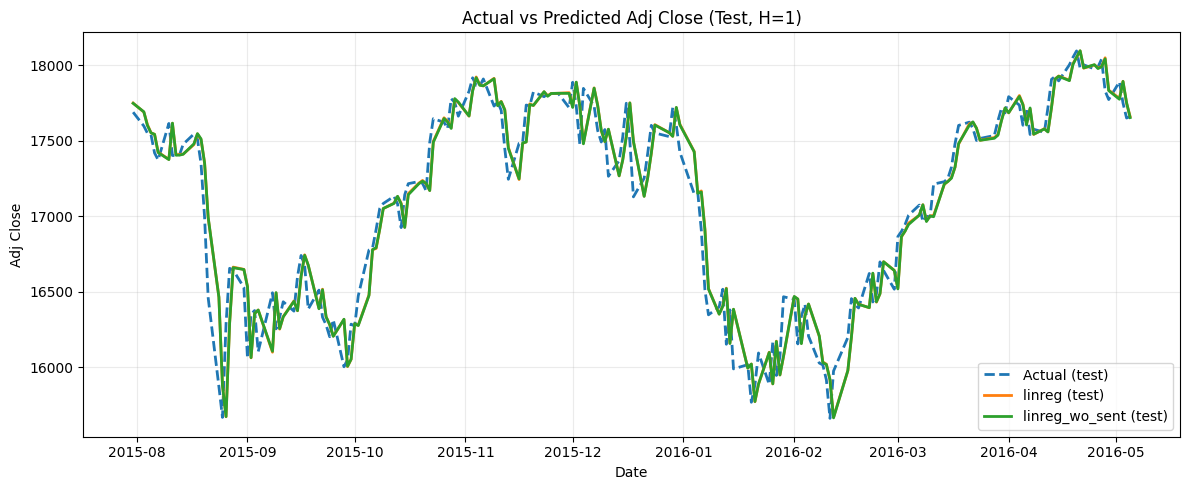

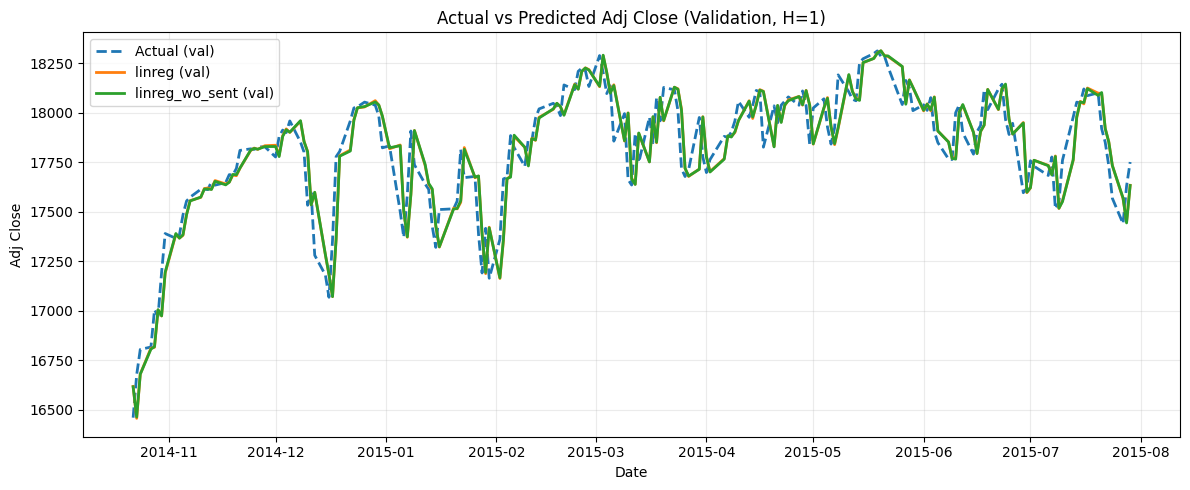

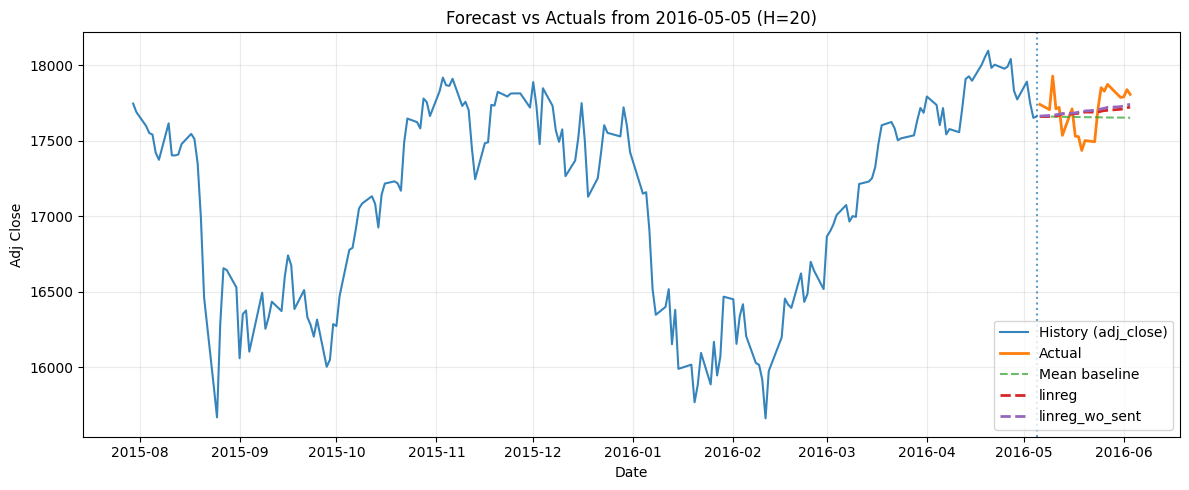

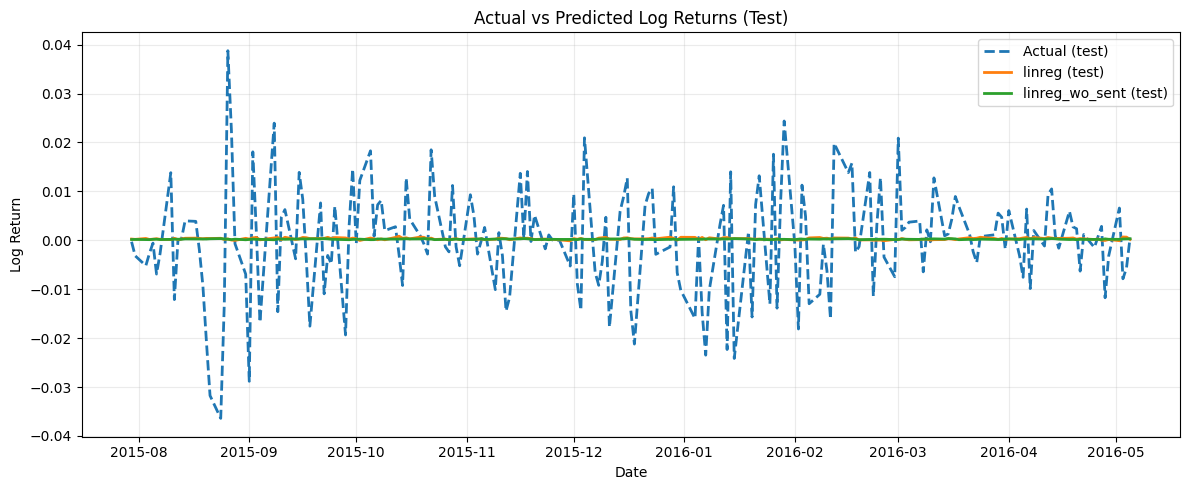

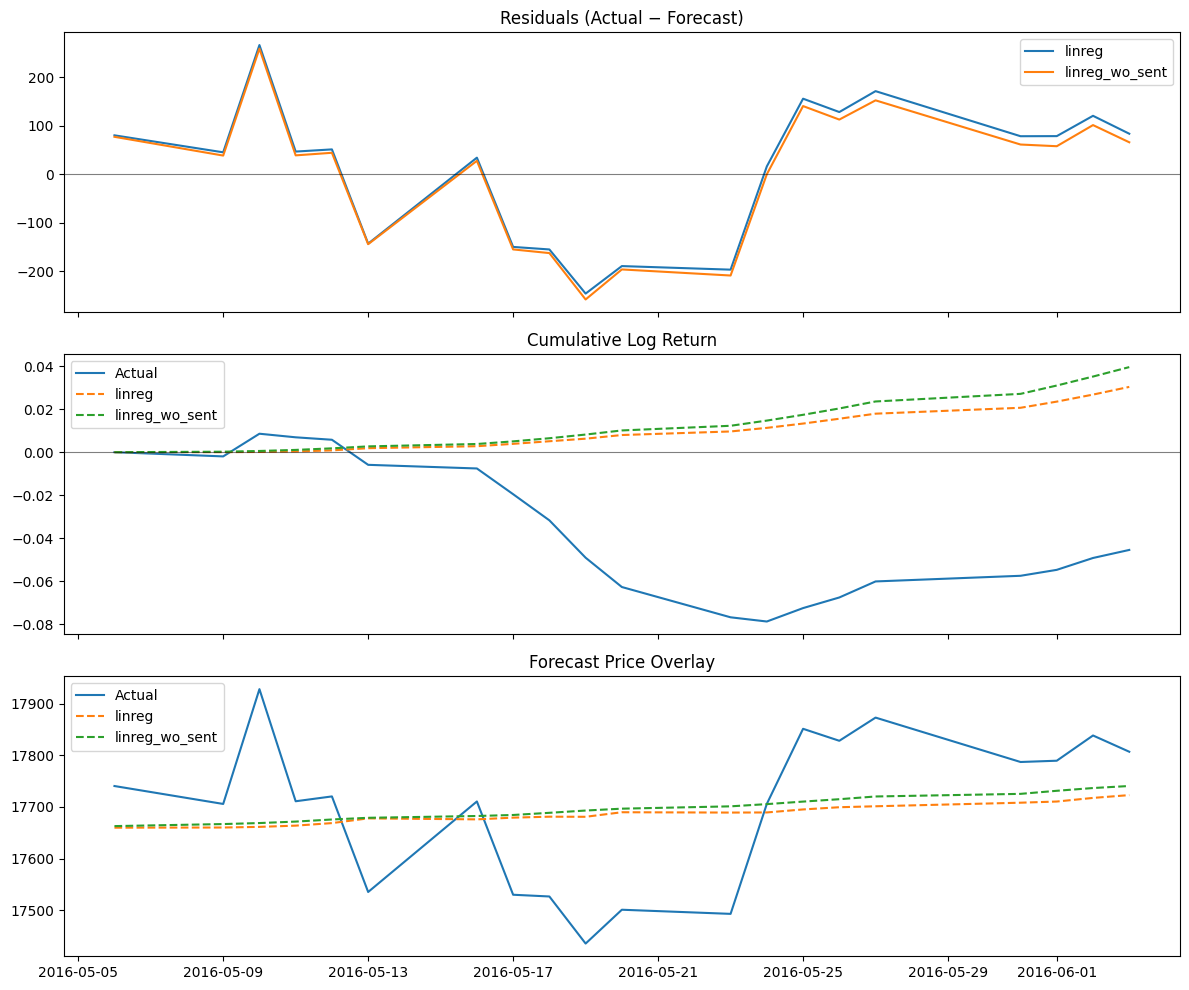

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME_LINREG}_actual_vs_predicted_adj_close_test.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME_LINREG}_actual_vs_predicted_adj_close_val.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME_LINREG}_forecast.png")
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME_LINREG}_returns.png", "test")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME_LINREG}_forecast_diagnostics.png")

In [8]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,alpha,l1_ratio,max_iter,eta0,learning_rate,random_state
0,linreg,0.000012,0.722608,3500,0.0001,invscaling,42
1,linreg_wo_sent,0.000012,0.722608,3500,0.0001,invscaling,42


In [9]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,linreg,0.008160,0.000117,0.010831,0.000138,0.529275
1,linreg_wo_sent,0.008164,0.000117,0.010834,-0.000286,0.529275


In [10]:
metrics_summary = results_to_df(results, ["metrics", "test", "per_horizon"])
metrics_summary = metrics_summary[metrics_summary["model"] == MODEL_NAME_LINREG]
metrics_summary

,model,per_horizon,mae,mse,rmse,r2,directional_accuracy
0,linreg,1,0.008164,0.000119,0.010914,-0.000350,0.528497
1,linreg,2,0.008176,0.000119,0.010910,0.000101,0.497409
2,linreg,3,0.008197,0.000120,0.010950,-0.001779,0.523316
3,linreg,4,0.008244,0.000121,0.010979,-0.000915,0.523316
4,linreg,5,0.008244,0.000120,0.010968,0.001192,0.523316
5,linreg,6,0.008260,0.000121,0.010981,0.001358,0.538860
6,linreg,7,0.008292,0.000121,0.011011,-0.000189,0.528497
7,linreg,8,0.008273,0.000121,0.010986,0.000817,0.533679
8,linreg,9,0.008187,0.000119,0.010914,0.007559,0.595855
9,linreg,10,0.008256,0.000121,0.010978,-0.002805,0.533679


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()